In [2]:

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c data-science-bowl-2018

!mkdir -p dsb2018
!unzip -q data-science-bowl-2018.zip -d dsb2018
!mkdir -p dsb2018/stage1_train
!unzip -q dsb2018/stage1_train.zip -d dsb2018/stage1_train


 99% 354M/358M [00:00<00:00, 612MB/s]
100% 358M/358M [00:00<00:00, 657MB/s]


In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob

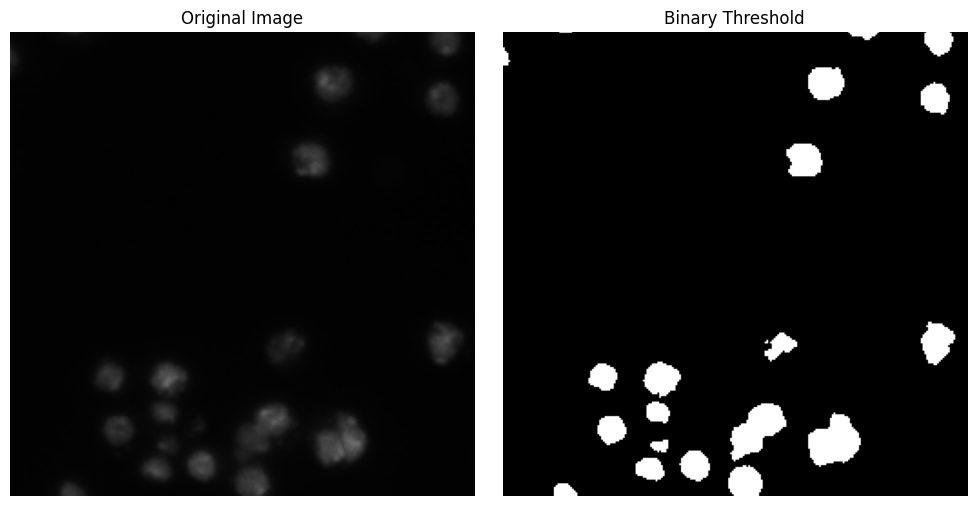

In [26]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

data_dir = "dsb2018/stage1_train"
ids = sorted(next(os.walk(data_dir))[1])

img_id = ids[0]
img_path = os.path.join(data_dir, img_id, "images", f"{img_id}.png")

img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

if np.mean(gray_img) > 127:
    gray_img = cv2.bitwise_not(gray_img)

_, binary = cv2.threshold(gray_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(binary, cmap="gray")
plt.title("Binary Threshold")
plt.axis("off")

plt.tight_layout()
plt.show()

In [30]:
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

img_simple = img_rgb.copy()
cv2.drawContours(img_simple, contours, -1, (255, 0, 0), 2)

print("Nuclei detected (Without Markers):", len(contours))

Nuclei detected (Without Markers): 21


In [31]:
kernel = np.ones((3,3), np.uint8)

open_img = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)
bg = cv2.dilate(open_img, kernel, iterations=3)

dist = cv2.distanceTransform(open_img, cv2.DIST_L2, 5)
_, fg = cv2.threshold(dist, 0.25 * dist.max(), 255, 0)
fg = np.uint8(fg)

unknown = cv2.subtract(bg, fg)

_, markers = cv2.connectedComponents(fg)
markers = markers + 1
markers[unknown == 255] = 0

img_ws = img_rgb.copy()
markers = cv2.watershed(img_ws, markers)

img_ws[markers == -1] = [255, 0, 0]

cell_count = np.max(markers) - 1
print("Nuclei detected (With Markers):", cell_count)

Nuclei detected (With Markers): 19


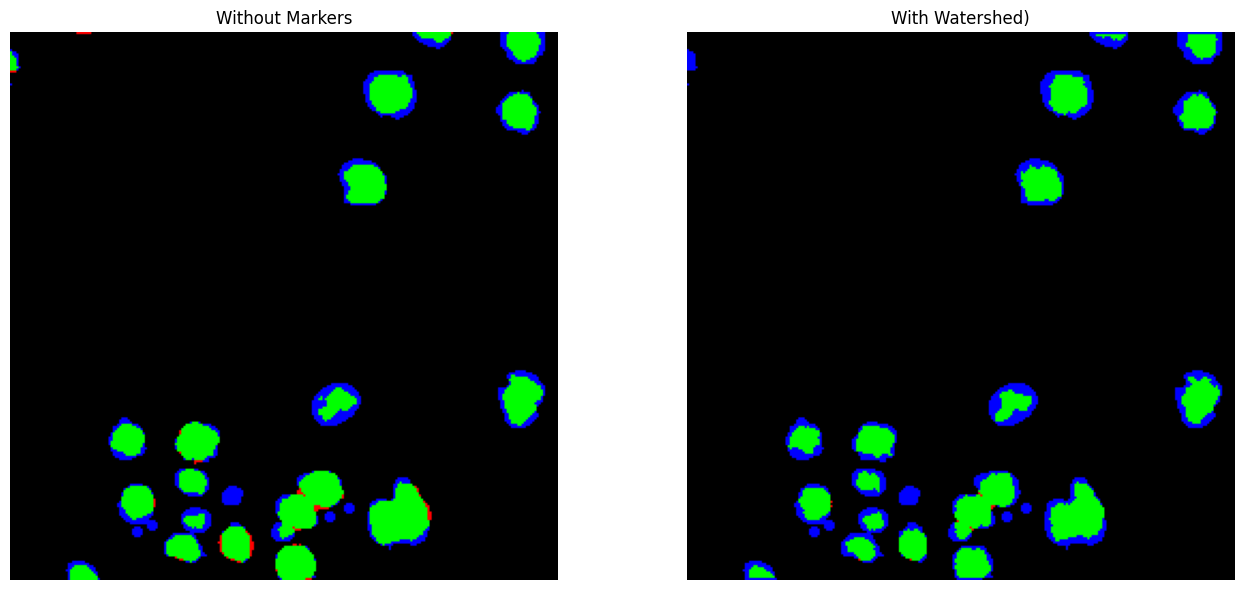

In [33]:
mask_folder = os.path.join(data_dir, img_id, "masks")
gt_mask = np.zeros(gray_img.shape, dtype=np.uint8)

for f in os.listdir(mask_folder):
    m = cv2.imread(os.path.join(mask_folder, f), 0)
    gt_mask = cv2.bitwise_or(gt_mask, m)

y_true = gt_mask > 0
y_pred_simple = binary > 0

# --- Without Markers ---
inter1 = np.logical_and(y_true, y_pred_simple)
union1 = np.logical_or(y_true, y_pred_simple)

iou_simple = np.sum(inter1) / np.sum(union1)
dice_simple = 2 * np.sum(inter1) / (np.sum(y_true) + np.sum(y_pred_simple))

# --- With Watershed ---
ws_mask = np.zeros_like(gt_mask)
ws_mask[markers > 1] = 255
y_pred_ws = ws_mask > 0

inter2 = np.logical_and(y_true, y_pred_ws)
union2 = np.logical_or(y_true, y_pred_ws)

iou_ws = np.sum(inter2) / np.sum(union2)
dice_ws = 2 * np.sum(inter2) / (np.sum(y_true) + np.sum(y_pred_ws))

# print("=== METRICS COMPARISON ===")
# print(f"IoU  - Without: {iou_simple:.4f} | With: {iou_ws:.4f}")
# print(f"Dice - Without: {dice_simple:.4f} | With: {dice_ws:.4f}")


def error_map(y_t, y_p):
    img = np.zeros_like(img_rgb)
    img[y_t & y_p] = [0, 255, 0]
    img[~y_t & y_p] = [255, 0, 0]
    img[y_t & ~y_p] = [0, 0, 255]
    return img

err_simple = error_map(y_true, y_pred_simple)
err_ws = error_map(y_true, y_pred_ws)

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.imshow(err_simple)
plt.title(f"Without Markers")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(err_ws)
plt.title(f"With Watershed")
plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
from tqdm import tqdm

data_dir = "dsb2018/stage1_train"
ids = next(os.walk(data_dir))[1]

records = []

print(f"Processing {len(ids)} images...")

for img_id in tqdm(ids):

    img_path = os.path.join(data_dir, img_id, "images", f"{img_id}.png")
    mask_dir = os.path.join(data_dir, img_id, "masks")

    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    if np.mean(gray) > 127:
        gray = cv2.bitwise_not(gray)

    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    gt = np.zeros(gray.shape, dtype=np.uint8)
    for f in os.listdir(mask_dir):
        m = cv2.imread(os.path.join(mask_dir, f), 0)
        gt = cv2.bitwise_or(gt, m)

    y_true = gt > 0
    y_pred_simple = binary > 0

    inter1 = np.sum(np.logical_and(y_true, y_pred_simple))
    union1 = np.sum(np.logical_or(y_true, y_pred_simple))

    iou_simple = inter1 / (union1 + 1e-8)
    dice_simple = 2 * inter1 / (np.sum(y_true) + np.sum(y_pred_simple) + 1e-8)

    kernel = np.ones((3,3), np.uint8)
    open_img = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)
    bg = cv2.dilate(open_img, kernel, iterations=3)

    dist = cv2.distanceTransform(open_img, cv2.DIST_L2, 5)
    _, fg = cv2.threshold(dist, 0.5 * dist.max(), 255, 0)
    fg = np.uint8(fg)

    unknown = cv2.subtract(bg, fg)

    _, markers = cv2.connectedComponents(fg)
    markers = markers + 1
    markers[unknown == 255] = 0

    img_ws = img.copy()
    markers = cv2.watershed(img_ws, markers)

    ws_mask = np.zeros_like(gt)
    ws_mask[markers > 1] = 255
    y_pred_ws = ws_mask > 0

    inter2 = np.sum(np.logical_and(y_true, y_pred_ws))
    union2 = np.sum(np.logical_or(y_true, y_pred_ws))

    iou_ws = inter2 / (union2 + 1e-8)
    dice_ws = 2 * inter2 / (np.sum(y_true) + np.sum(y_pred_ws) + 1e-8)

    records.append({"Method": "Without Markers", "IoU": iou_simple, "Dice": dice_simple})
    records.append({"Method": "With Watershed", "IoU": iou_ws, "Dice": dice_ws})

df = pd.DataFrame(records)
final_result = df.groupby("Method").mean().round(4)

print("\n=== FINAL AVERAGE METRICS ===")
display(final_result)

Processing 670 images...


100%|██████████| 670/670 [00:30<00:00, 21.76it/s]


=== FINAL AVERAGE METRICS ===


,IoU,Dice
Method,,
With Watershed,0.6284,0.7454
Without Markers,0.7788,0.8571
